# Task 3 — Exploratory Data Analysis and Feature Engineering

**Project:** Early Identification of University Students at Risk of Dropping Out  
**Dataset:** UCI *Predict Students' Dropout and Academic Success*  
**Prediction point:** End of the first semester  
**Outcome:** Multiclass `Dropout`, `Enrolled`, or `Graduate`; operational risk is the future model's probability of `Dropout`.

This notebook implements the Task 3 workflow and records the analytical decisions that will feed Task 4. The held-out test set is created before any learned preprocessing, feature selection, diagnostic importance, or PCA fitting. It is saved for later evaluation and is not used to make Task 3 decisions.

## 1. Setup and reproducibility

The workflow uses a fixed random seed of 42. Running the next cell regenerates all processed datasets, tables, figures, and fitted preprocessing artifacts from the original UCI CSV.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, display

def find_project_root(start: Path) -> Path:
    # Locate the extracted project root from Jupyter's working directory.
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src" / "task3_analysis.py").is_file():
            return candidate
    raise FileNotFoundError(
        "Project root not found. Keep the notebook inside the extracted Task 3 folder."
    )

ROOT = find_project_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.task3_analysis import run_analysis

artifacts = run_analysis()
with (ROOT / "reports" / "task3_analysis_summary.json").open(encoding="utf-8") as handle:
    summary = json.load(handle)

print(f"Rows analysed: {summary['data_scope']['rows']:,}")
print(f"Training rows: {summary['data_scope']['train_rows']:,}")
print(f"Held-out test rows: {summary['data_scope']['test_rows']:,}")
print(f"Random seed: {summary['reproducibility']['random_state']}")

Matplotlib is building the font cache; this may take a moment.


Rows analysed: 4,424
Training rows: 3,539
Held-out test rows: 885
Random seed: 42


## 2. Data quality, cleaning, and prediction scope

The source has no machine-readable missing values, blank strings, or exact duplicate rows. Two documented occupation fields use code `99` for a blank/not-stated response; these are converted to an explicit `Unknown/not stated` category rather than treated as a numerical value. The source spelling `Nacionality` is standardized to `Nationality`.

The six second-semester academic variables are excluded from the primary dataset because they would not be known at the end-of-first-semester prediction point. This is a temporal leakage safeguard, not a claim that those variables are unimportant.

Source-wide quality checks are performed before splitting because they validate schema and integrity rather than learn decision rules. All target-dependent EDA, outlier review, feature screening, diagnostic importance, and PCA results below use the training partition only.

In [2]:
quality_items = {
    "Raw rows": summary["quality"]["raw_rows"],
    "Raw columns": summary["quality"]["raw_columns"],
    "Machine missing values": summary["quality"]["machine_missing"],
    "Blank strings": summary["quality"]["blank_strings"],
    "Exact duplicate rows": summary["quality"]["exact_duplicates"],
    "Mother occupation code 99": summary["quality"]["mother_occupation_code_99"],
    "Father occupation code 99": summary["quality"]["father_occupation_code_99"],
    "Engineered missing values": summary["quality"]["engineered_missing"],
}
display(pd.Series(quality_items, name="value").to_frame())

scope = summary["data_scope"]
display(pd.Series(scope, name="count").to_frame())

,value
Raw rows,4424
Raw columns,37
Machine missing values,0
Blank strings,0
Exact duplicate rows,0
Mother occupation code 99,17
Father occupation code 99,19
Engineered missing values,0


,count
rows,4424
original_predictors,36
second_semester_predictors_excluded,6
original_predictors_available_at_prediction,30
engineered_features_added,9
features_before_audit_only_exclusion,39
audit_only_features_excluded_from_default_matrix,8
model_input_columns_before_encoding,31
transformed_features_after_encoding,125
selected_features,30


## 3. Training target distribution

The training outcome is moderately imbalanced: graduates are the largest group, while enrolled students are the smallest. Accuracy alone would therefore be misleading in Task 4. The planned model comparison will emphasize dropout recall and precision, macro-averaged metrics, confusion matrices, and ranking performance for the top-risk intervention list.

,outcome,count,share,random_recall_at_30pct
0,Dropout,1137,0.321277,0.3
1,Enrolled,635,0.179429,0.3
2,Graduate,1767,0.499294,0.3


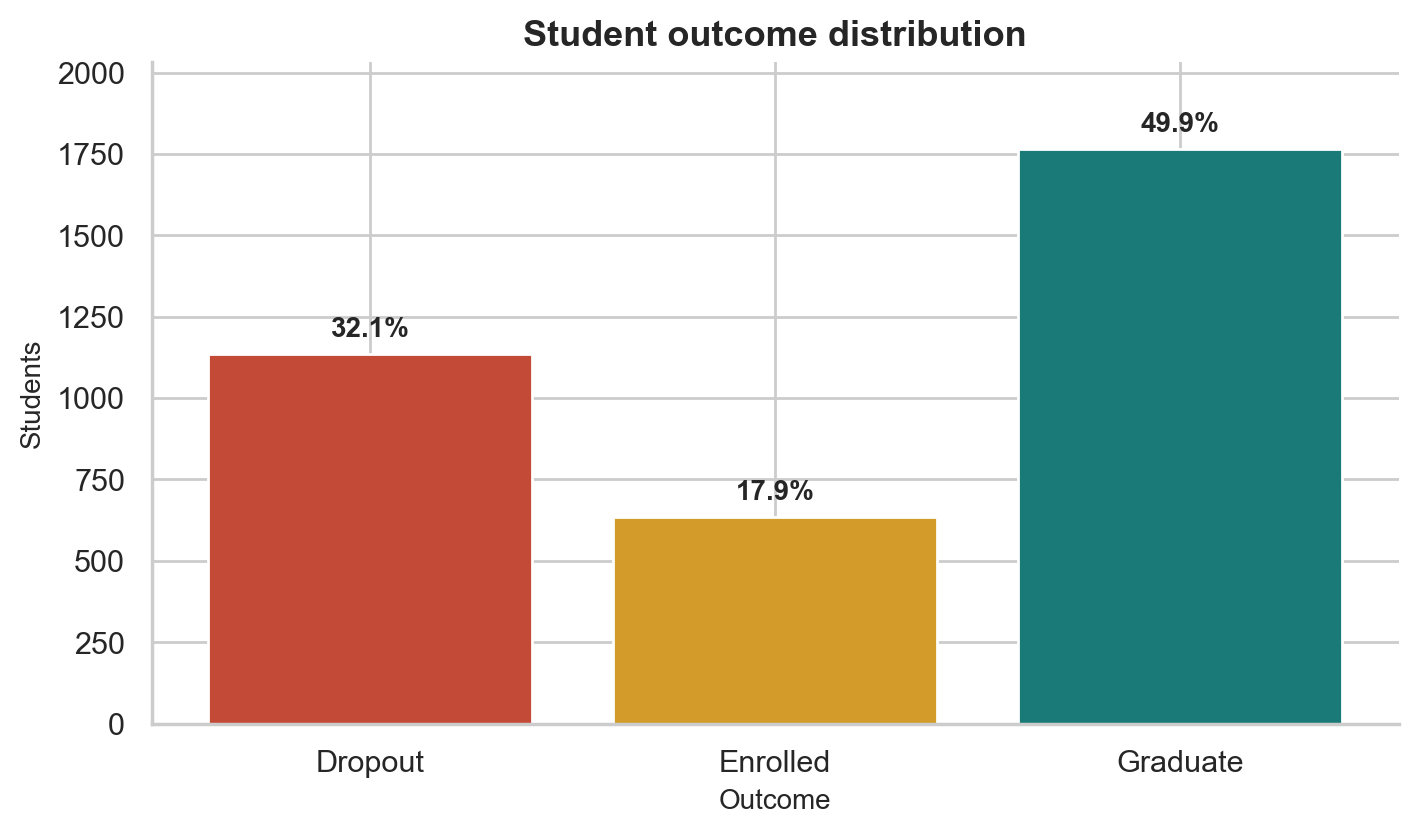

In [3]:
target_distribution = pd.read_csv(ROOT / "reports" / "tables" / "task3" / "target_distribution.csv")
display(target_distribution)
display(Image(filename=str(ROOT / "reports" / "figures" / "task3" / "01_target_distribution.png")))

## 4. Feature engineering

Nine features are created from information available by the prediction point:

- `first_sem_approval_rate`: approved units divided by enrolled units; academic completion signal.
- `first_sem_evaluation_intensity`: evaluations divided by enrolled units; assessment activity signal.
- `first_sem_no_evaluation_rate`: units without evaluations divided by enrolled units; disengagement signal.
- `first_sem_progress_index`: approval rate weighted by normalized first-semester grade; combines completion and performance.
- `academic_preparation_gap`: admission grade minus previous-qualification grade; captures change between prior and entry performance.
- `first_sem_no_enrollment_flag`: identifies students with no first-semester unit enrollment.
- `first_choice_flag`: application order equals one; proxy for program preference.
- `financial_risk_flag`: debtor or tuition not up to date; combines immediate financial-friction indicators.
- `nontraditional_age_flag`: age 25 or older at enrollment; retained for subgroup audit but excluded from the default model matrix.

Ratios use safe division and return zero when the denominator is zero. This prevents artificial missing or infinite values while preserving a separate no-enrollment flag.

In [4]:
engineered_summary = pd.read_csv(ROOT / "reports" / "tables" / "task3" / "engineered_feature_summary.csv")
display(engineered_summary.round(3))

,engineered_feature,count,mean,std,min,25%,50%,75%,max
0,first_sem_approval_rate,3539.0,0.697,0.367,0.0,0.5,0.833,1.00,1.000
1,first_sem_evaluation_intensity,3539.0,1.289,0.573,0.0,1.0,1.200,1.60,3.500
2,first_sem_no_evaluation_rate,3539.0,0.023,0.105,0.0,0.0,0.000,0.00,1.000
3,first_sem_progress_index,3539.0,0.448,0.248,0.0,0.3,0.533,0.64,0.944
4,academic_preparation_gap,3539.0,-5.808,12.749,-70.0,-11.7,-5.200,0.00,63.500


## 5. Exploratory analysis

The following plots describe relationships in the training partition and are used for understanding, not for claiming causality. Particularly large descriptive differences appear for first-semester progress and for financial-friction indicators. Sensitive attributes are kept in the processed audit dataset so later fairness checks remain possible, but direct demographic fields are excluded from the default modelling matrix pending the Task 5 ethics review.

,feature,group,students,dropouts,dropout_rate
0,Gender,Female,2298,581,0.252829
1,Gender,Male,1241,556,0.448026
2,Tuition fees up to date,Not up to date,419,364,0.868735
3,Tuition fees up to date,Up to date,3120,773,0.247756
4,Debtor,No,3150,888,0.281905
5,Debtor,Yes,389,249,0.640103
6,Scholarship holder,No,2645,1022,0.386389
7,Scholarship holder,Yes,894,115,0.128635


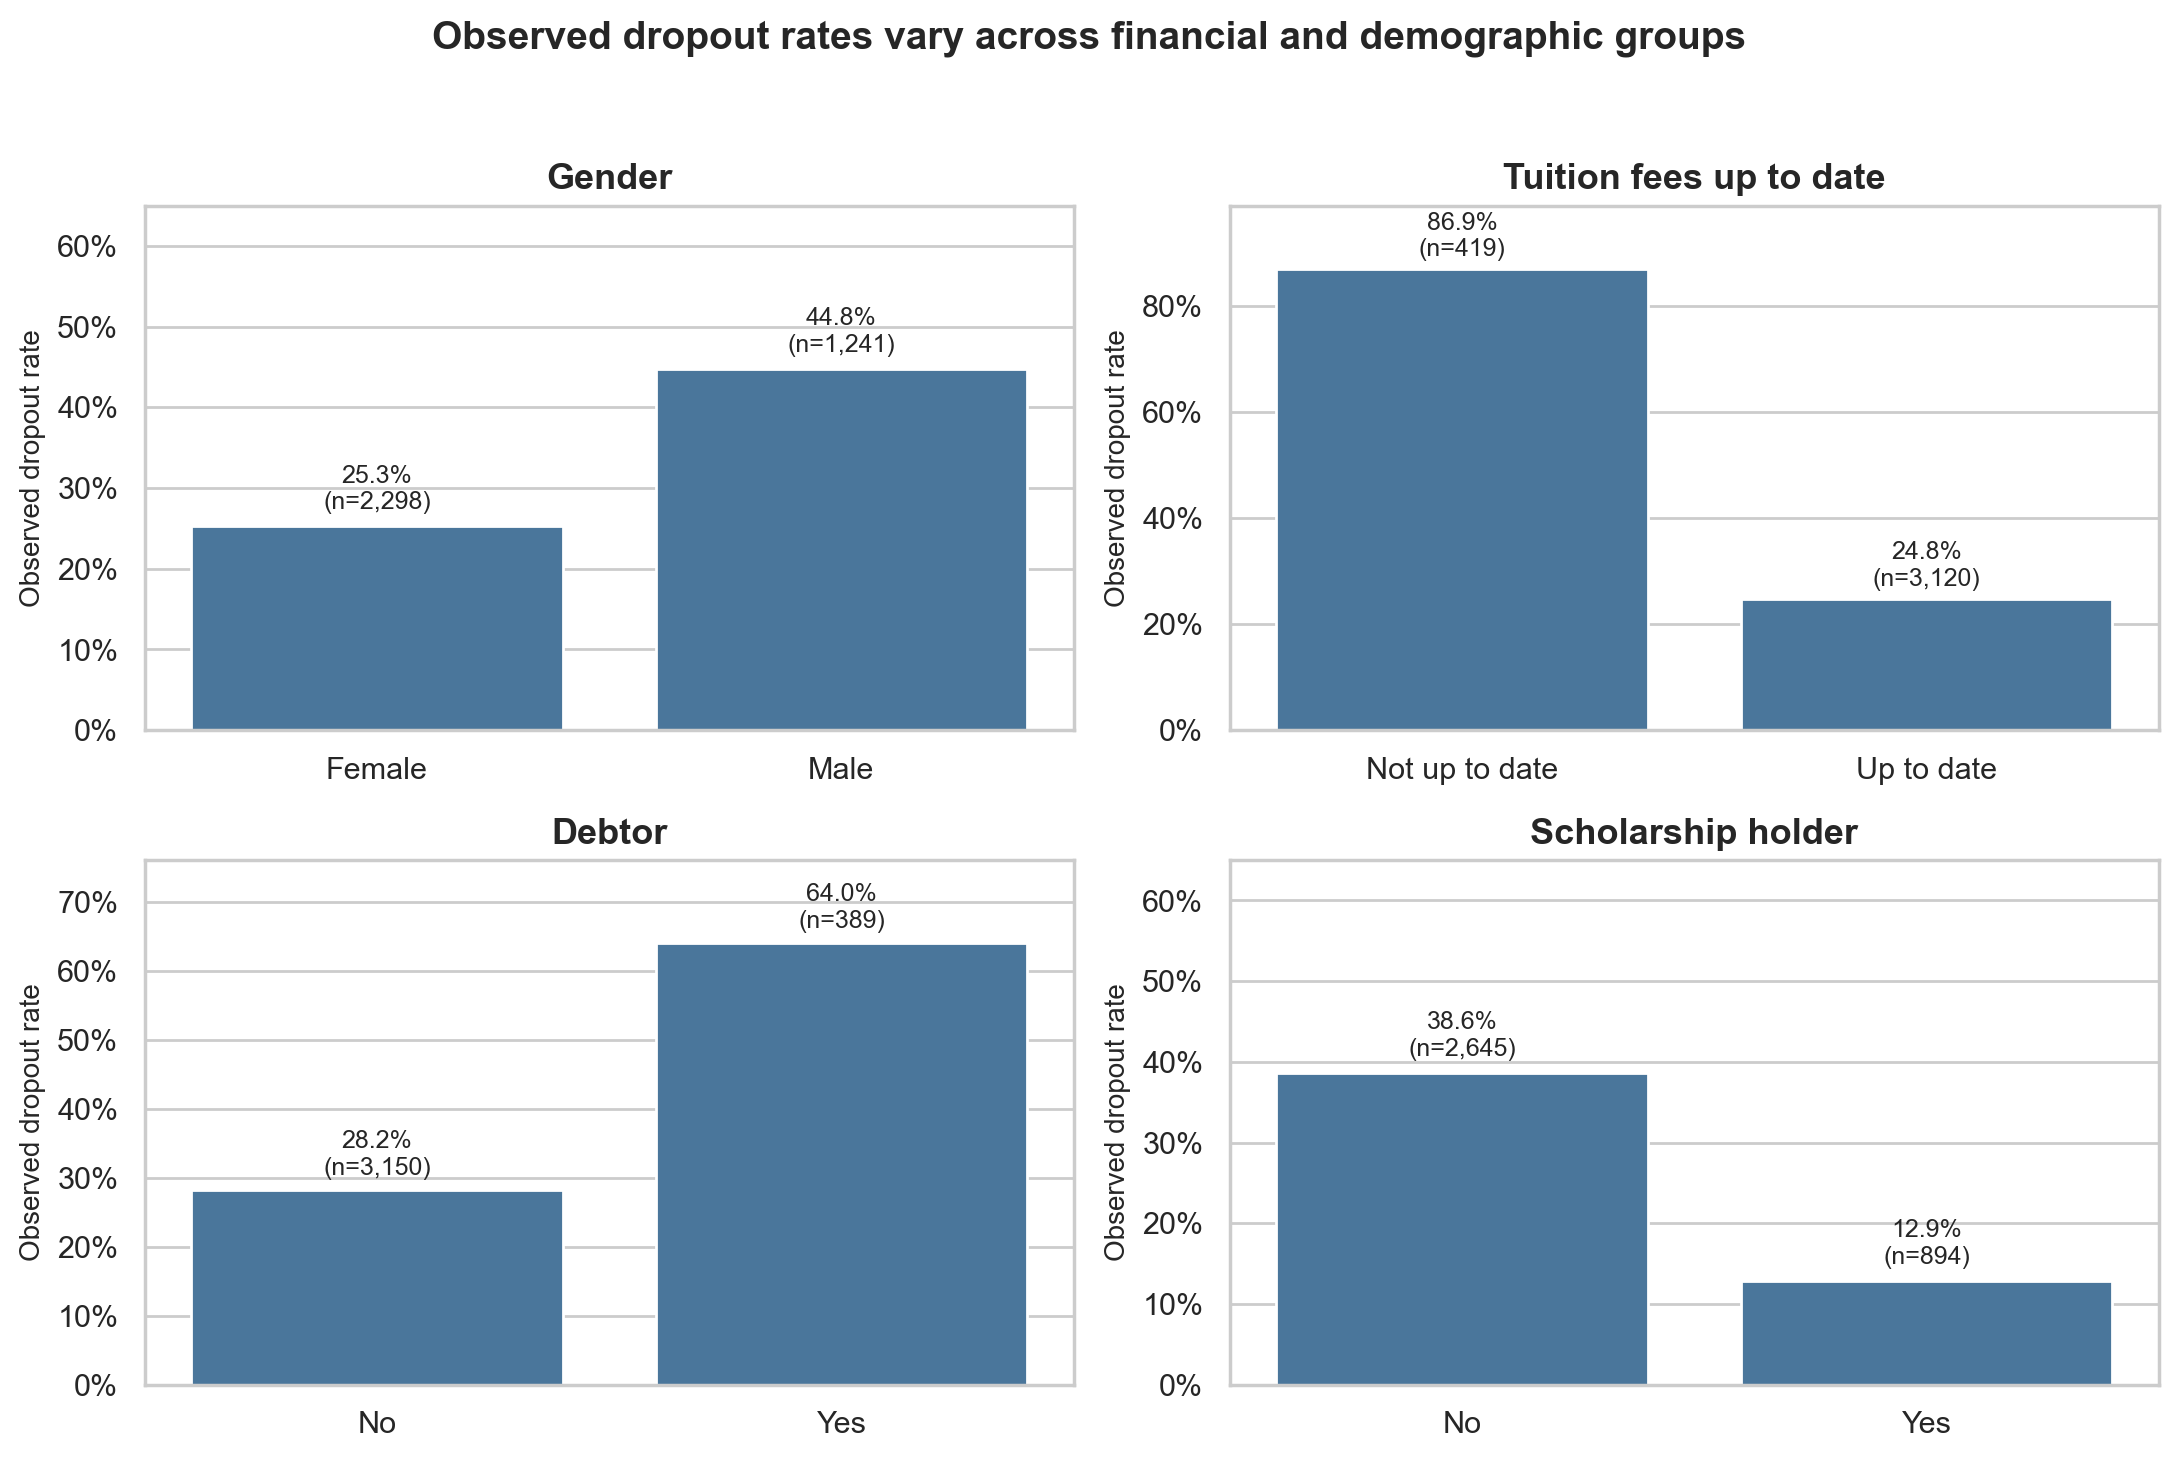

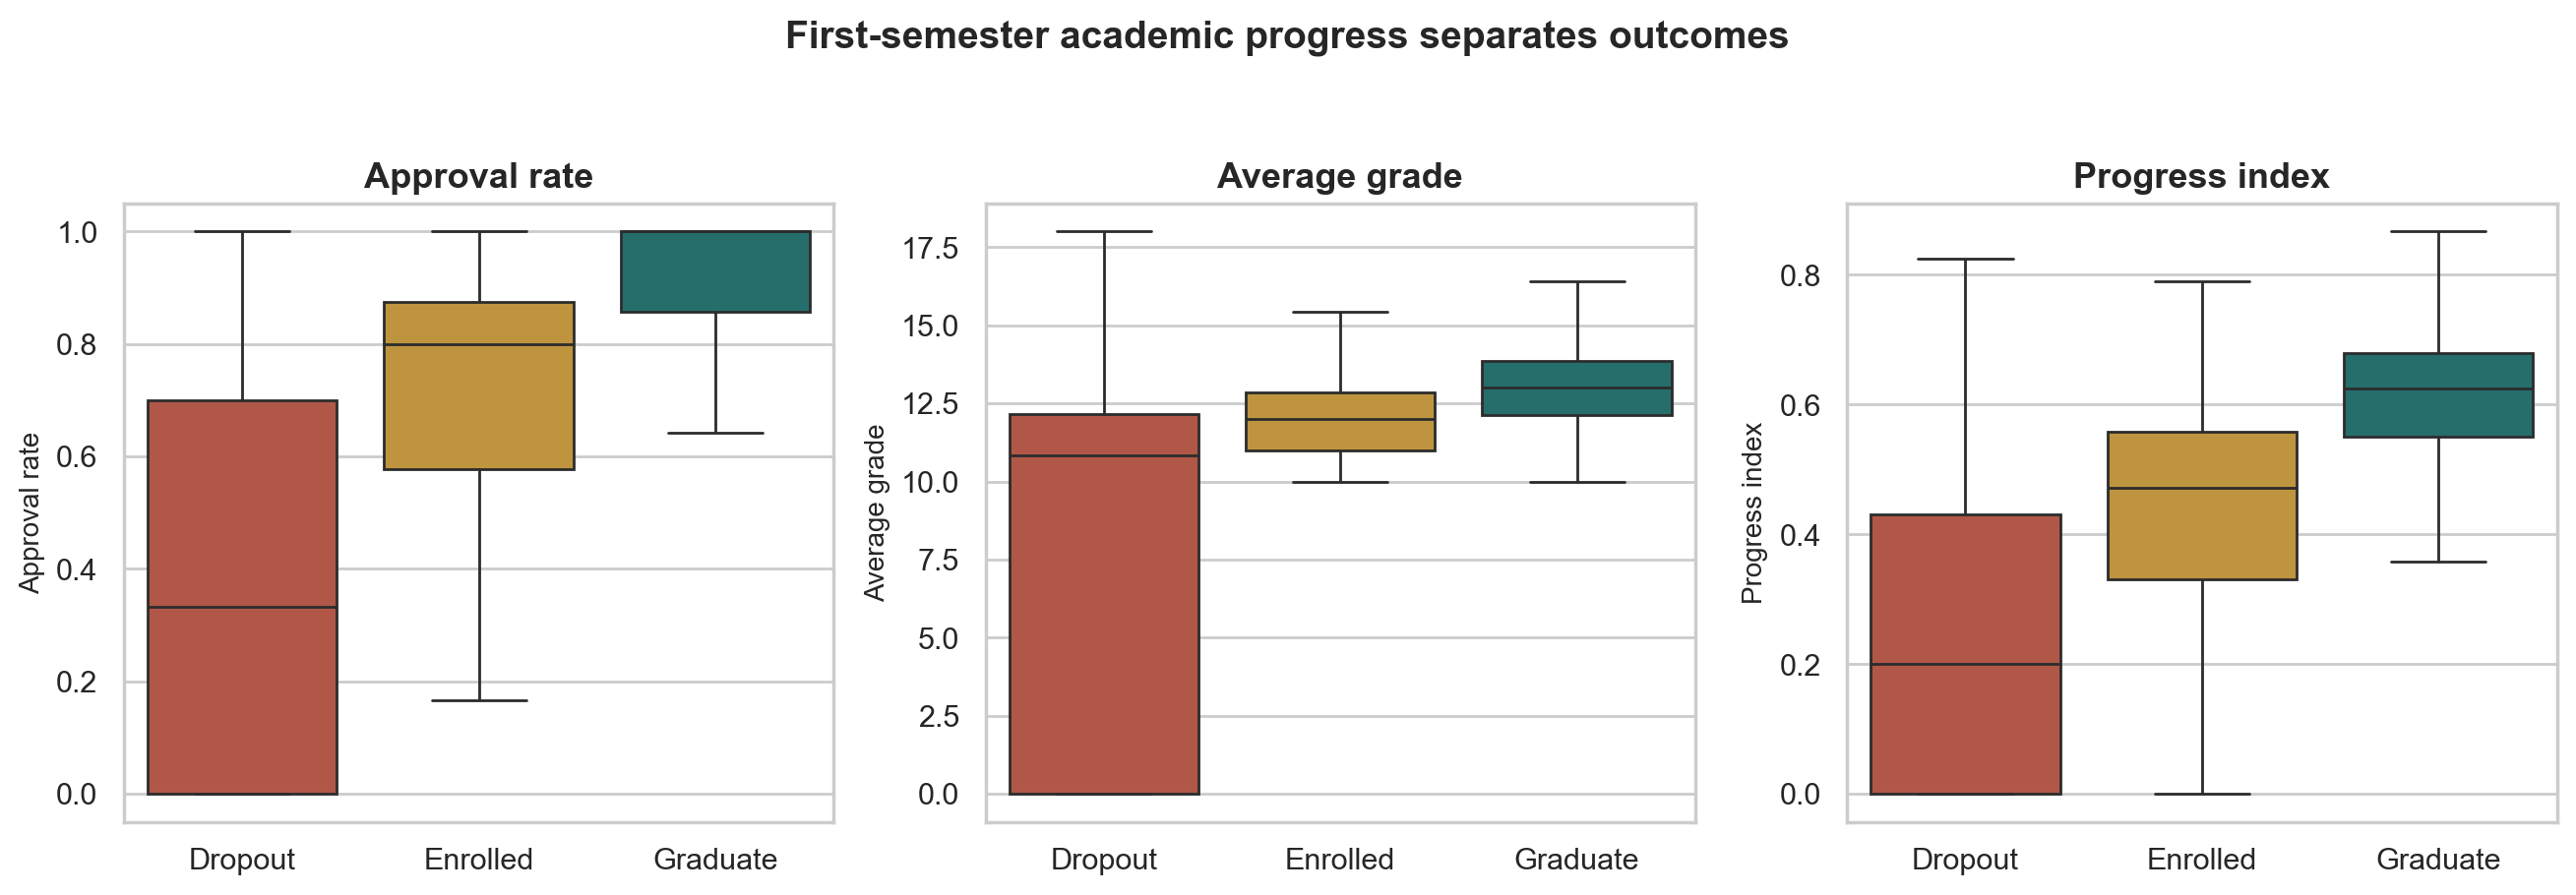

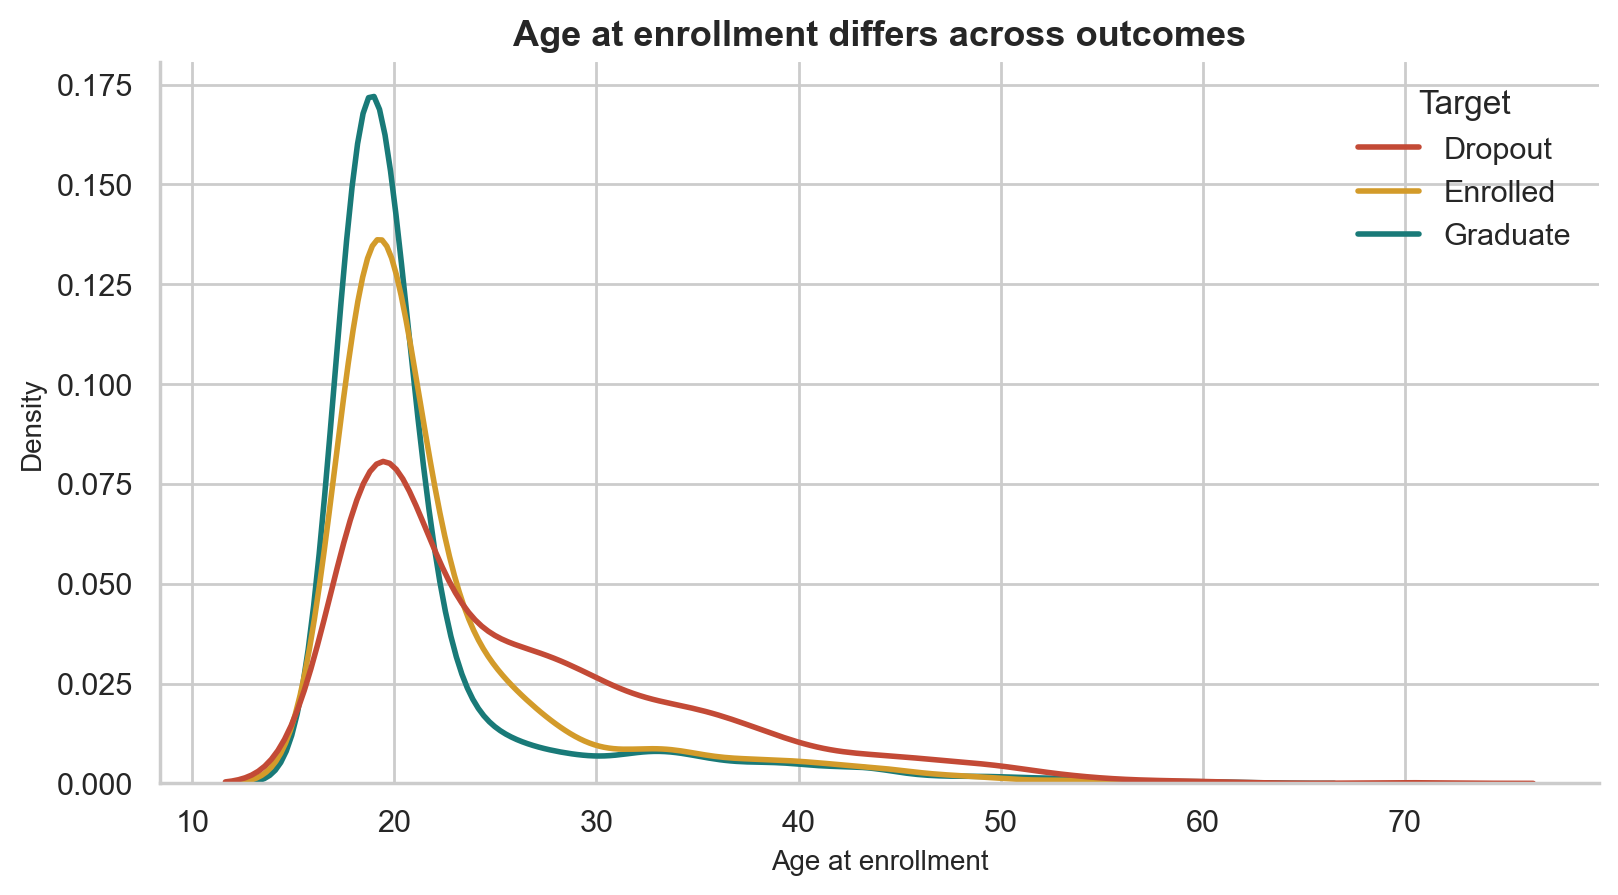

In [5]:
subgroup_preview = pd.read_csv(ROOT / "reports" / "tables" / "task3" / "subgroup_descriptive_preview.csv")
display(subgroup_preview)
display(Image(filename=str(ROOT / "reports" / "figures" / "task3" / "02_key_factor_dropout_rates.png")))
display(Image(filename=str(ROOT / "reports" / "figures" / "task3" / "03_academic_features_by_outcome.png")))
display(Image(filename=str(ROOT / "reports" / "figures" / "task3" / "04_age_distribution_by_outcome.png")))

### Numeric associations and outliers

Spearman correlations are used because several variables are counts, bounded rates, or non-normally distributed. IQR flags identify values worth reviewing but are not automatic deletion rules. The reviewed extremes are plausible student records and remain inside documented source ranges, so they are retained. Robust scaling is used for continuous variables to reduce their influence without discarding legitimate students.

,variable,minimum,q1,median,q3,maximum,iqr_lower_fence,iqr_upper_fence,iqr_flag_count,iqr_flag_share,disposition
0,Curricular units 1st sem (grade),0.0,11.0,12.32,13.399,18.875,7.4015,16.9975,592,0.167279,Retain; validated as plausible or structurally...
1,Curricular units 1st sem (credited),0.0,0.0,0.00,0.000,20.000,0.0000,0.0000,467,0.131958,Retain; validated as plausible or structurally...
2,Application order,0.0,1.0,1.00,2.000,9.000,-0.5000,3.5000,431,0.121786,Retain; validated as plausible or structurally...
3,first_sem_evaluation_intensity,0.0,1.0,1.20,1.600,3.500,0.1000,2.5000,378,0.106810,Retain; validated as plausible or structurally...
4,Age at enrollment,17.0,19.0,20.00,25.000,70.000,10.0000,34.0000,358,0.101159,Retain; validated as plausible or structurally...
5,Curricular units 1st sem (enrolled),0.0,5.0,6.00,7.000,26.000,2.0000,10.0000,342,0.096637,Retain; validated as plausible or structurally...
6,academic_preparation_gap,-70.0,-11.7,-5.20,0.000,63.500,-29.2500,17.5500,317,0.089573,Retain; validated as plausible or structurally...
7,first_sem_no_evaluation_rate,0.0,0.0,0.00,0.000,1.000,0.0000,0.0000,245,0.069229,Retain; validated as plausible or structurally...
8,Curricular units 1st sem (without evaluations),0.0,0.0,0.00,0.000,12.000,0.0000,0.0000,245,0.069229,Retain; validated as plausible or structurally...
9,Curricular units 1st sem (approved),0.0,3.0,5.00,6.000,26.000,-1.5000,10.5000,141,0.039842,Retain; validated as plausible or structurally...


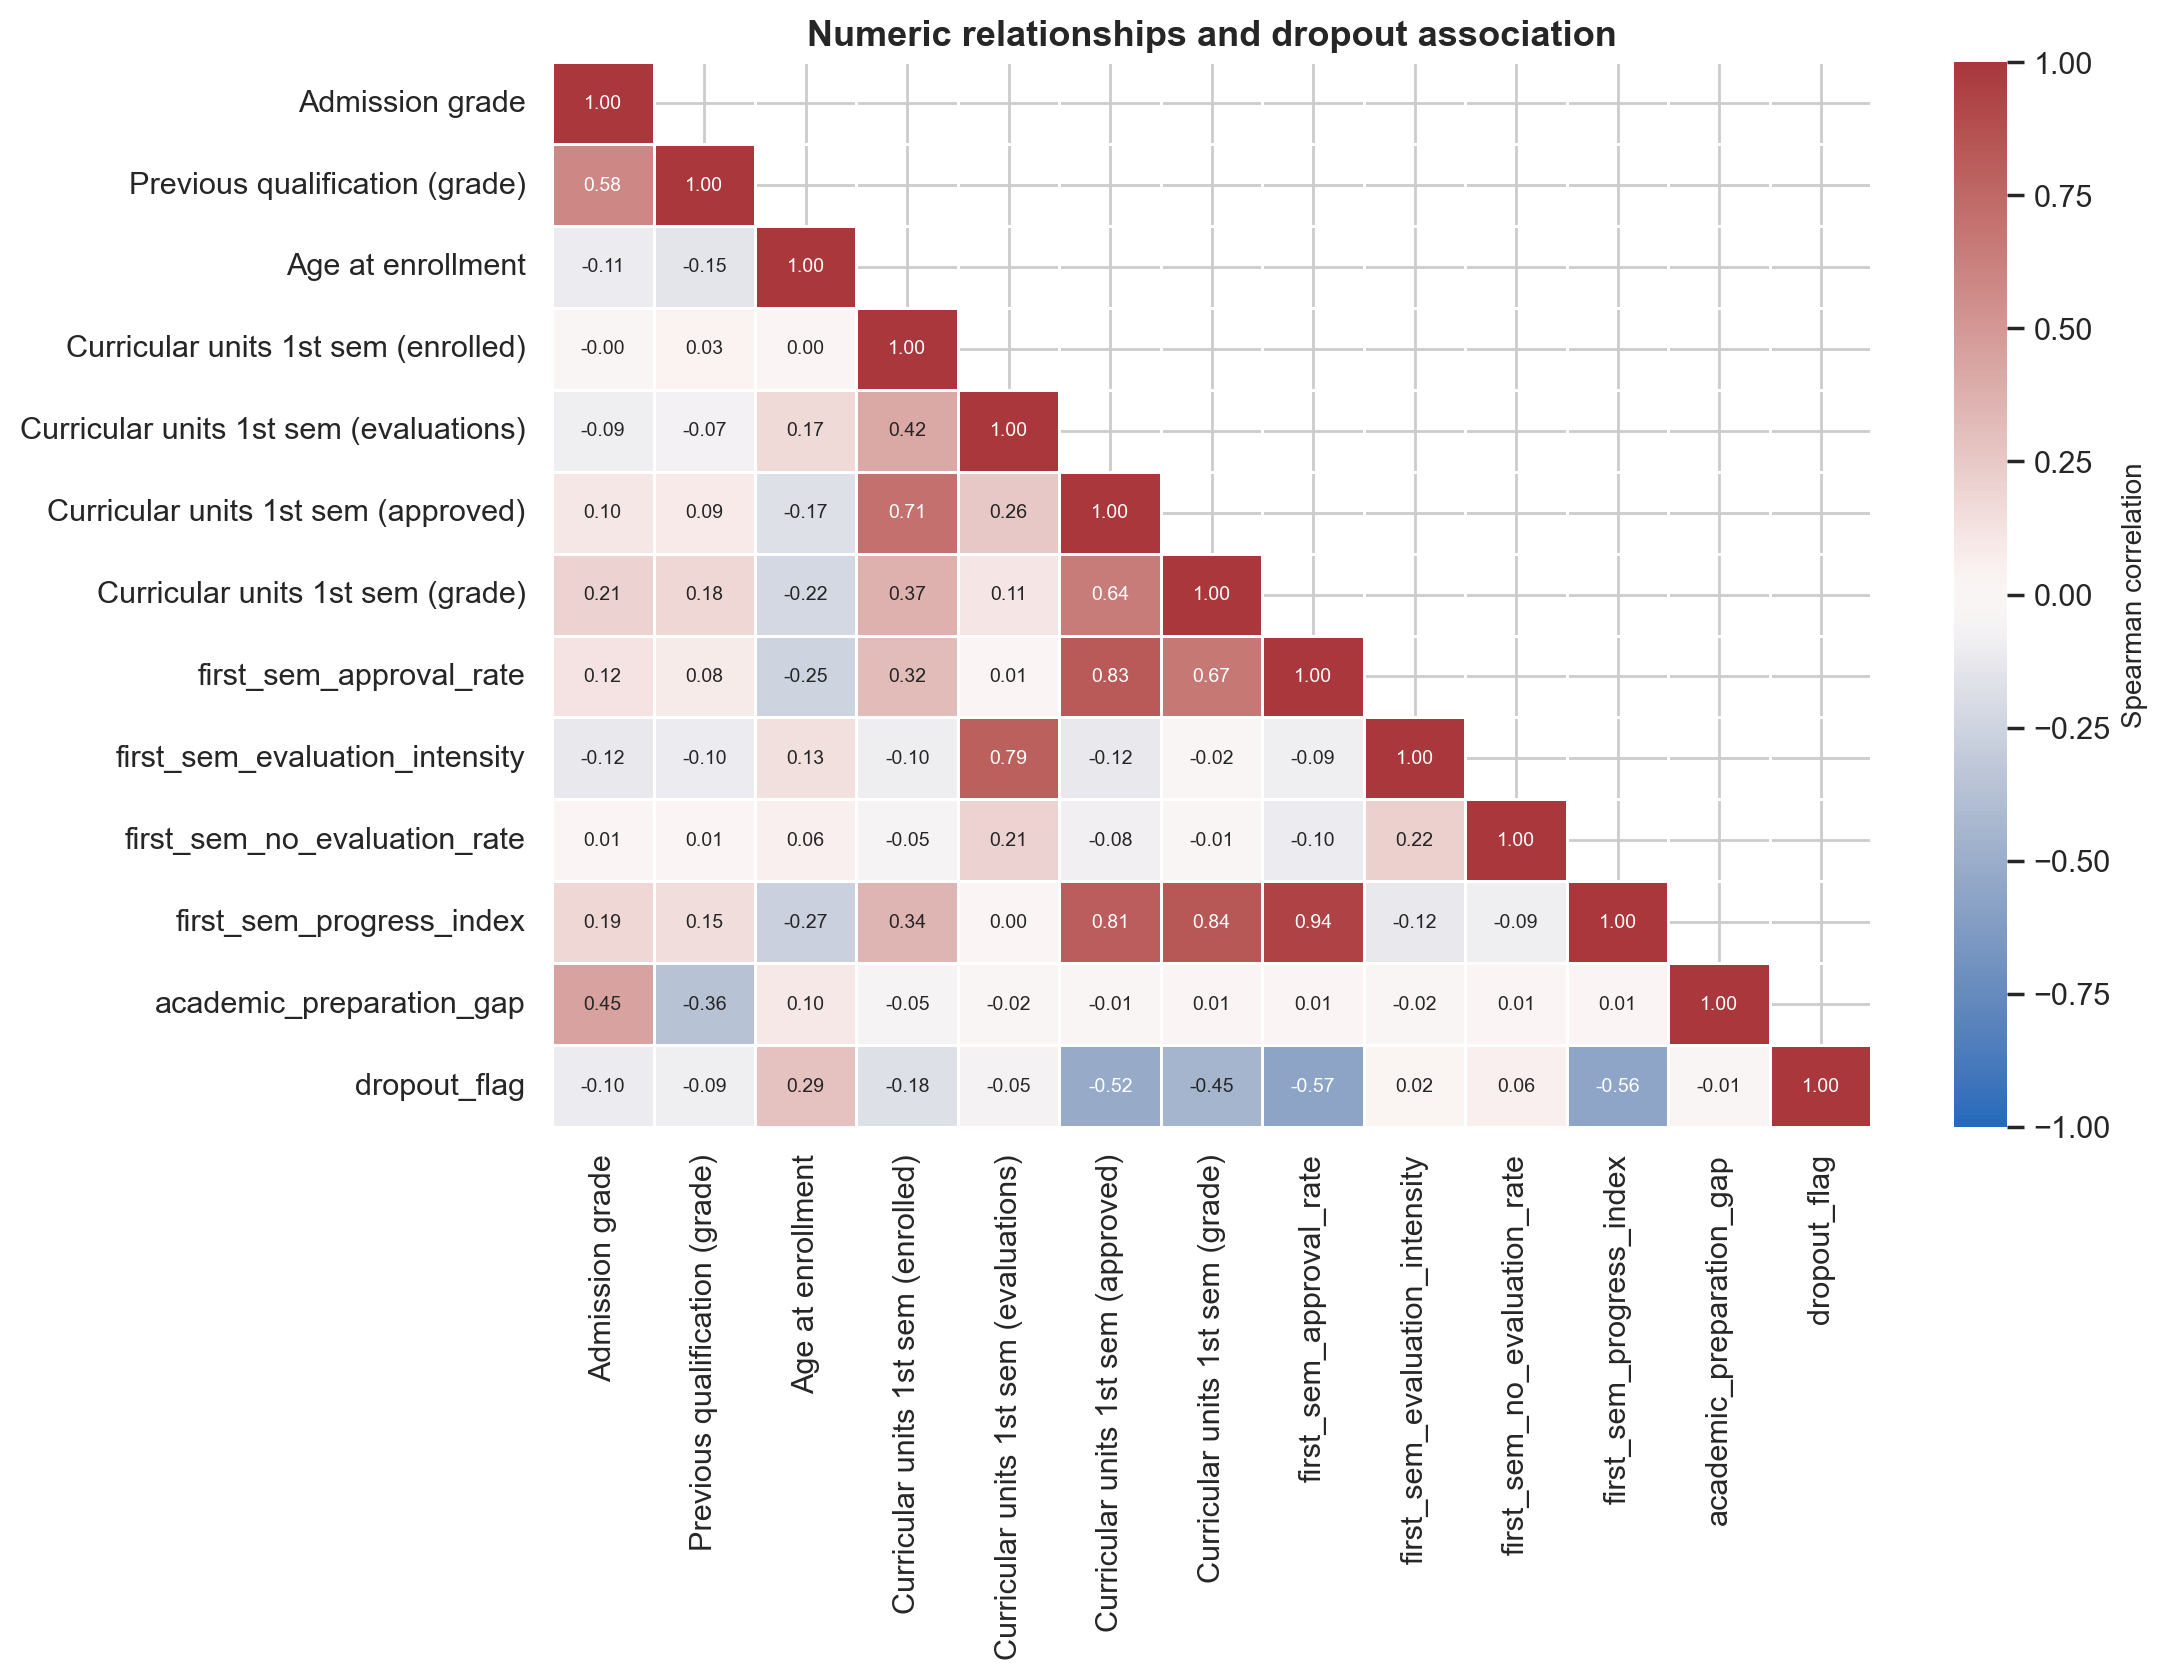

In [6]:
outlier_review = pd.read_csv(ROOT / "reports" / "tables" / "task3" / "outlier_review.csv")
display(outlier_review.sort_values("iqr_flag_count", ascending=False).head(15))
display(Image(filename=str(ROOT / "reports" / "figures" / "task3" / "05_numeric_correlation_heatmap.png")))

## 6. Preprocessing design

The primary data is split 80/20 using stratification before learned transformations. The preprocessing pipeline is fitted only on the 3,539 training rows:

- categorical variables: defensive mode imputation, then one-hot encoding;
- rare categories: grouped when fewer than 10 training records occur;
- numeric variables: defensive median imputation and `RobustScaler`;
- unseen test categories: ignored safely by the encoder.

Direct sensitive attributes (`Gender`, `Age at enrollment`, `Nationality`, `Marital Status`, `Displaced`, `Educational special needs`, `International`, and the engineered age flag) are not included in the default feature matrix. They remain available in the train/test audit files.

In [7]:
preprocessing_counts = {
    "Input columns before encoding": scope["model_input_columns_before_encoding"],
    "Encoded training features": scope["transformed_features_after_encoding"],
    "Selected features": scope["selected_features"],
}
display(pd.Series(preprocessing_counts, name="count").to_frame())

,count
Input columns before encoding,31
Encoded training features,125
Selected features,30


## 7. Feature selection and diagnostic importance

Mutual information is used as the primary filter method because it can detect nonlinear relationships between encoded features and the multiclass outcome. The top 30 transformed features are selected using training data only.

An Extra Trees classifier supplies a separate model-based importance view as a diagnostic cross-check. It is **not** presented as the final model or a Task 4 model comparison. Correlated and paired one-hot variables can divide or duplicate importance, so ranks should be interpreted as screening evidence rather than causal effects.

Top 15 mutual-information features


,feature,mutual_information,rank,selected_top_30
0,numeric__first_sem_progress_index,0.274225,1,True
1,numeric__first_sem_approval_rate,0.258018,2,True
2,numeric__Curricular units 1st sem (approved),0.236767,3,True
3,numeric__Curricular units 1st sem (grade),0.180428,4,True
4,numeric__first_sem_evaluation_intensity,0.110638,5,True
5,numeric__Curricular units 1st sem (evaluations),0.105312,6,True
6,categorical__Tuition fees up to date_0,0.092613,7,True
7,categorical__Tuition fees up to date_1,0.092613,8,True
8,categorical__financial_risk_flag_1,0.077776,9,True
9,categorical__financial_risk_flag_0,0.077776,10,True


Top 15 diagnostic model-based features


,feature,model_based_importance,rank
0,numeric__first_sem_approval_rate,0.110877,1
1,numeric__first_sem_progress_index,0.107946,2
2,numeric__Curricular units 1st sem (grade),0.054820,3
3,numeric__Curricular units 1st sem (approved),0.041124,4
4,categorical__Tuition fees up to date_1,0.038528,5
5,categorical__Tuition fees up to date_0,0.035646,6
6,numeric__first_sem_evaluation_intensity,0.035372,7
7,categorical__financial_risk_flag_1,0.025272,8
8,categorical__Scholarship holder_1,0.024599,9
9,categorical__Scholarship holder_0,0.022482,10


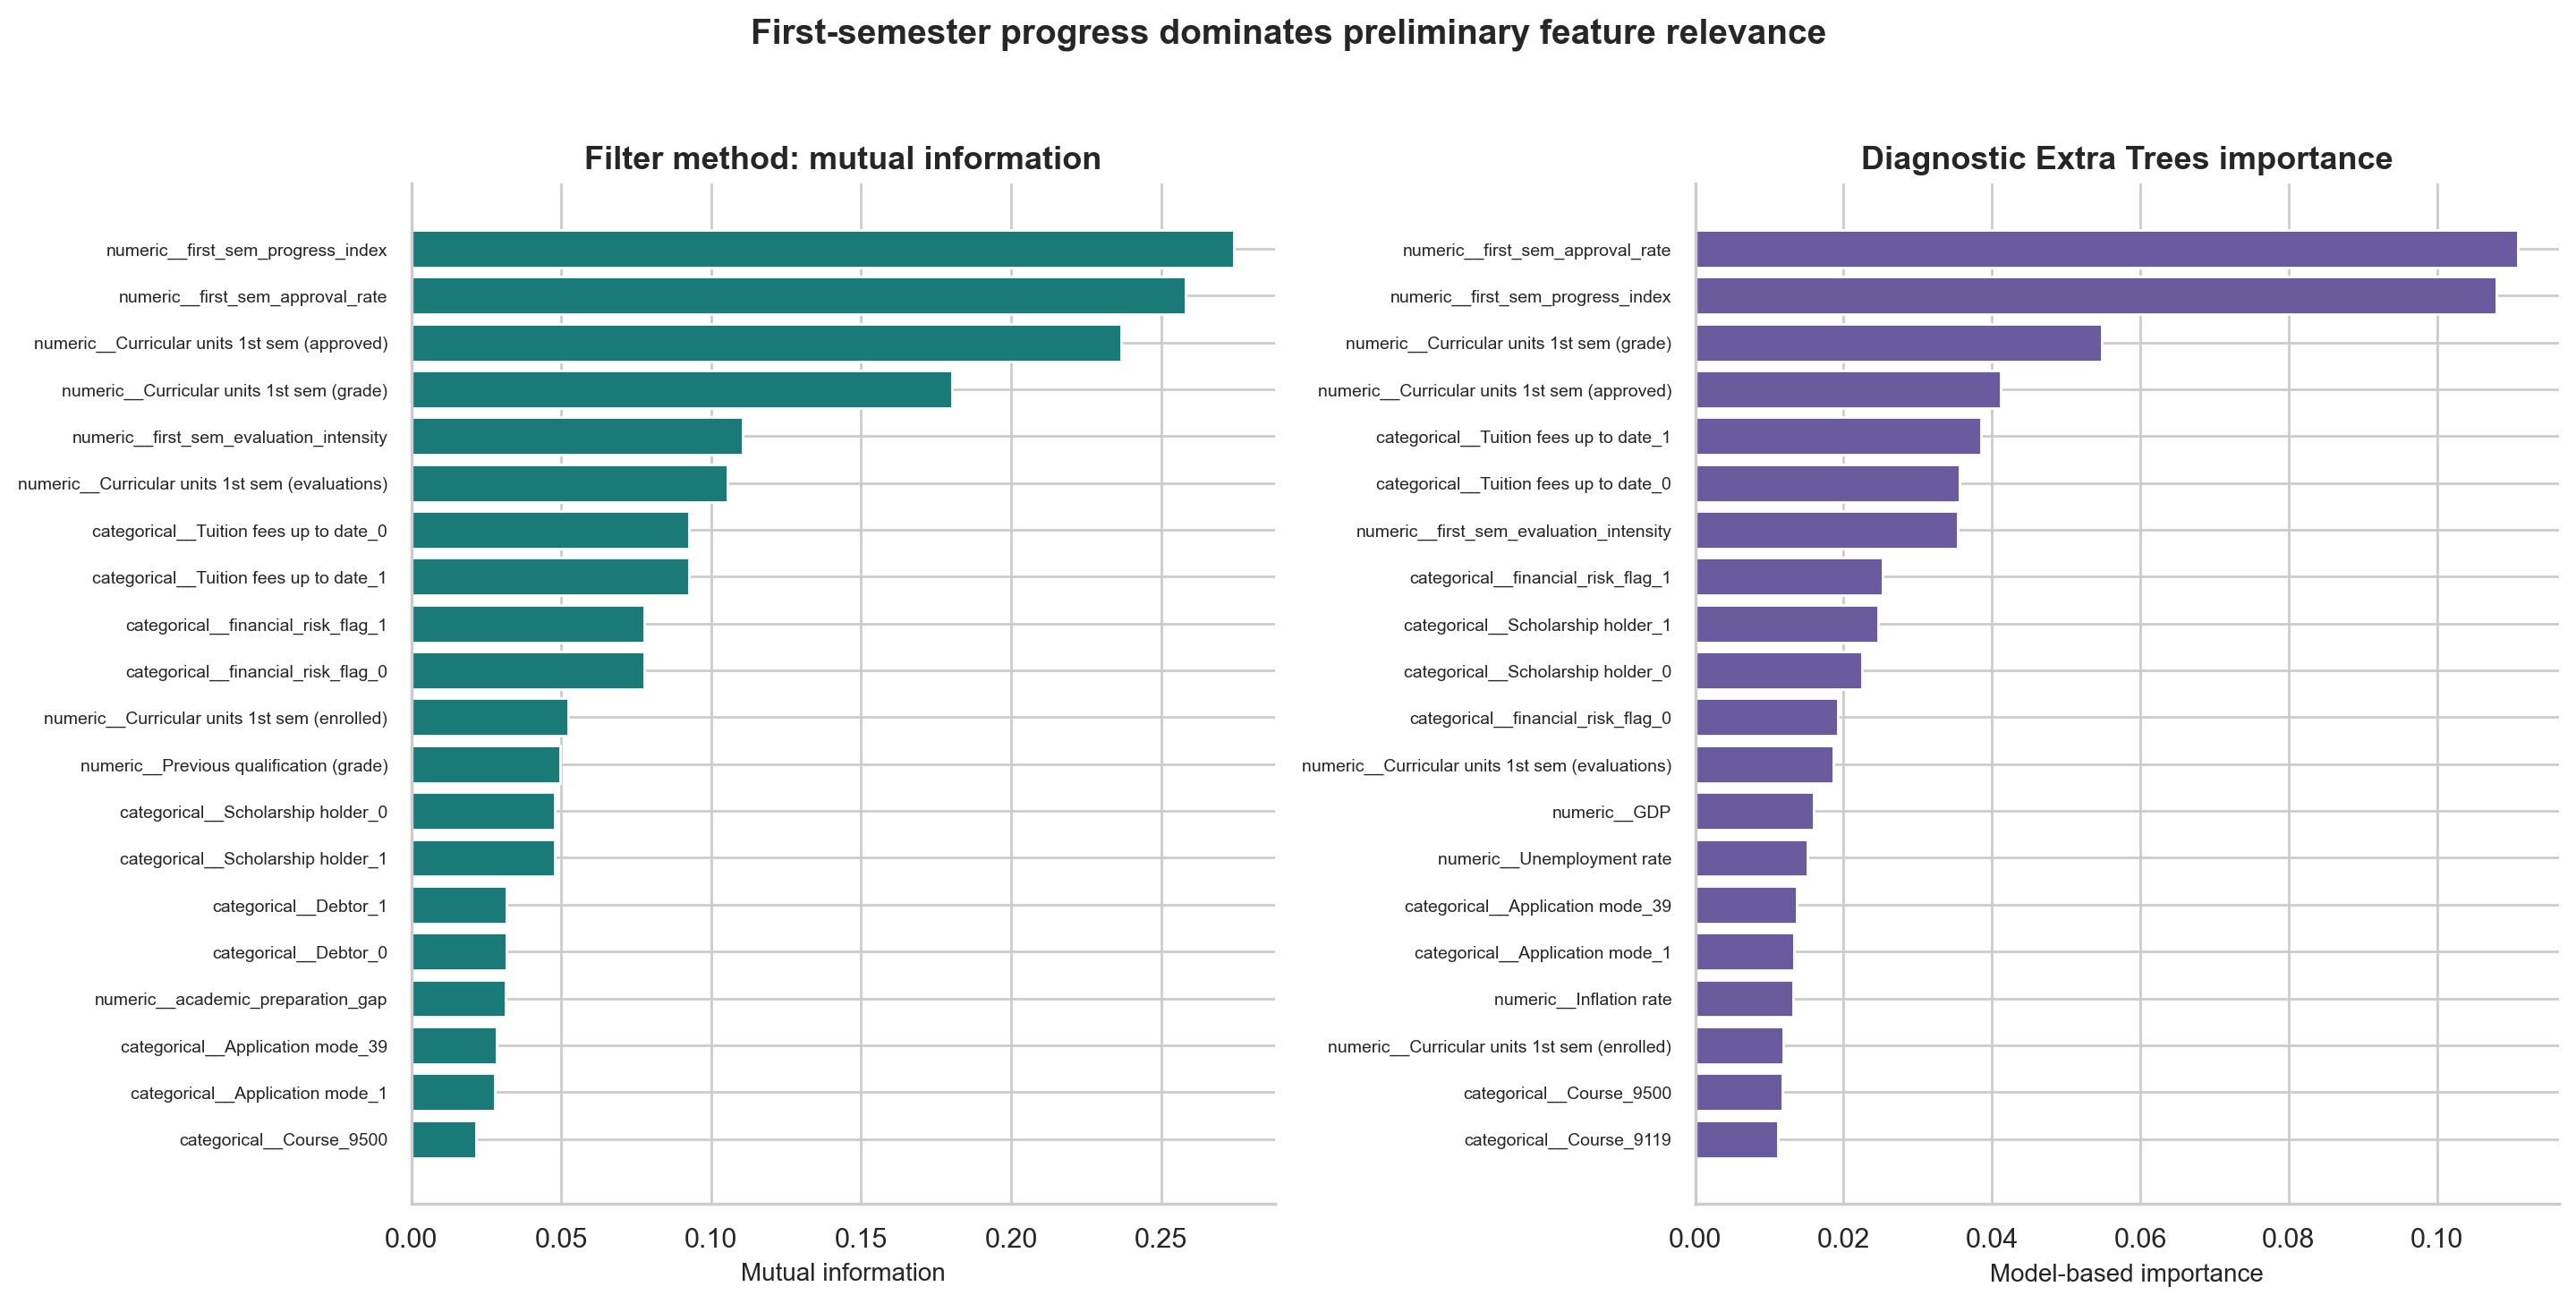

In [8]:
mi_ranking = pd.read_csv(ROOT / "reports" / "tables" / "task3" / "mutual_information_feature_ranking.csv")
model_importance = pd.read_csv(ROOT / "reports" / "tables" / "task3" / "diagnostic_model_feature_importance.csv")
print("Top 15 mutual-information features")
display(mi_ranking.head(15))
print("Top 15 diagnostic model-based features")
display(model_importance.head(15))
display(Image(filename=str(ROOT / "reports" / "figures" / "task3" / "06_feature_selection_and_importance.png")))

## 8. PCA dimensionality reduction

PCA is fitted to the standardized transformed training matrix. It is useful as a compact comparison for Task 4, but it trades away feature-level interpretability. The first two components explain only a small share of total variance, so the two-dimensional plot is exploratory rather than a basis for claiming clean class separation.

Nonlinear t-SNE/UMAP embeddings are not used here: they would add tuning and stability concerns without serving the immediate modelling need. PCA gives a deterministic variance benchmark that can be evaluated fairly in Task 4.

,value
Components for 80% variance,61.000000
Components for 90% variance,75.000000
Components for 95% variance,84.000000
Variance in first two components,0.094445


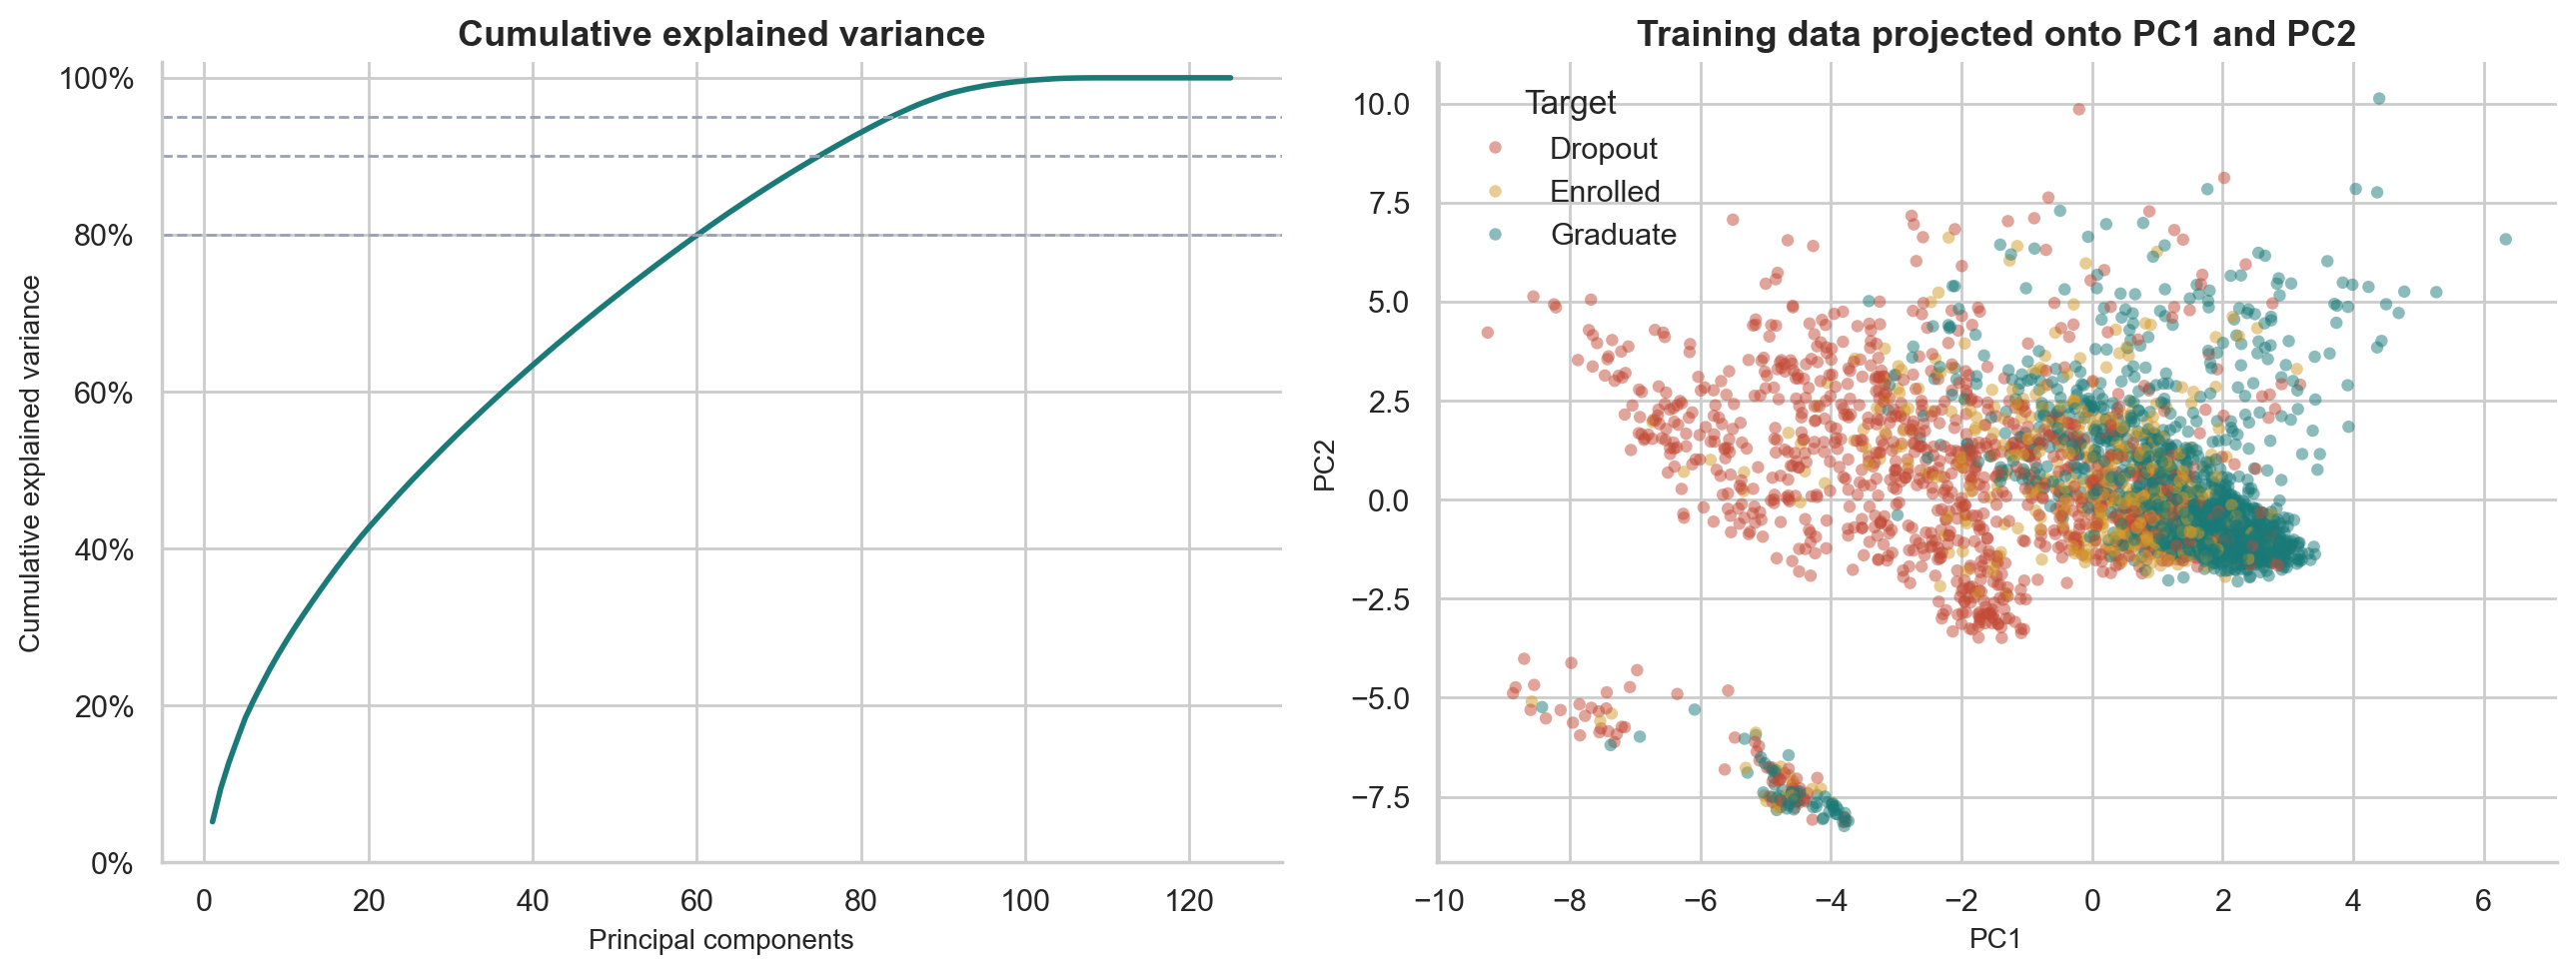

In [9]:
pca_counts = {
    "Components for 80% variance": summary["pca"]["components_for_80pct"],
    "Components for 90% variance": summary["pca"]["components_for_90pct"],
    "Components for 95% variance": summary["pca"]["components_for_95pct"],
    "Variance in first two components": summary["pca"]["first_two_cumulative"],
}
display(pd.Series(pca_counts, name="value").to_frame())
display(Image(filename=str(ROOT / "reports" / "figures" / "task3" / "07_pca_analysis.png")))

## 9. Task 3 conclusions and handoff to Task 4

1. The primary modelling dataset contains 4,424 students and 39 prediction-time features before sensitive/audit-only exclusions; 31 columns enter the default preprocessing matrix.
2. First-semester progress, approval rate, approved units, grades, and evaluation activity dominate both screening approaches. Financial-friction indicators also rank highly.
3. The dataset is class-imbalanced, so Task 4 must evaluate dropout recall and precision alongside macro metrics—not accuracy alone.
4. The 30-feature mutual-information subset and the PCA representations are saved as alternatives for Task 4. The interpretable non-PCA representation remains the default starting point.
5. The 885-row held-out test set remains untouched by fitted preprocessing and selection decisions. Task 4 should use cross-validation on the training set for model choice, then evaluate the chosen pipeline once on this test set.

**Limitations:** Results come from one Portuguese institution; associations are not causal; the data supports intervention after the first semester rather than at initial enrollment; rare subgroup fairness estimates may be unstable.

## 10. Reproducible outputs

- `data/processed/task3/`: cleaned, scoped, train/test, and selected-feature datasets
- `models/task3/`: fitted preprocessor, diagnostic importance model, selected-feature list, and PCA artifacts
- `reports/tables/task3/`: numerical EDA and reduction tables
- `reports/figures/task3/`: publication-ready plots
- `reports/task3_analysis_summary.json`: machine-readable record of decisions and headline results

The executable implementation is in `src/task3_analysis.py`; this notebook is its documented analytical report.